# Figure 6D — corrected Rippl-AI probability heatmap

Rerun **Kernel → Restart Kernel and Run All Cells** on the machine with the original `.mat`, raw LFP, and `rippl_AI` package.

**The figure uses the same 31,847-candidate global feature order and 30,162-candidate subset as Figure6_B.ipynb:** patients → channels in `pt_ch_mapping` → `sorted(glob(...))` files → rows within a file. Rippl-AI probabilities are calculated per block and stored **by exact feature-file path**, then concatenated in that global feature order. The code fails with an explicit message rather than silently assigning another candidate's probability if any file/row count does not match.

Changes from the uploaded D notebook: (1) no patient-count filtering of occupied bins, (2) include samples at both grid extrema, (3) represent empty bins by NaN rather than probability zero, (4) show actual mean probabilities on a truthful colorbar, (5) cluster boundary settings aligned with B (`KMeans` / KNN, distance threshold 0.4).

**Note:** Figure6_B.ipynb has the old `searchsorted(...) - 1` grid-edge behavior. For an *exact per-bin count comparison* apply the small B patch at the bottom of this notebook as well. Figure 6D now loads Figure 6B’s saved grid edges and checks all 400 cell counts before plotting; run B first.

In [1]:
import os
import glob
import collections
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
import umap.umap_ as umap
import rippl_AI

# Edit these if your data location has changed.
pathname = "/scratch/dazhang/MATLAB/"
raw_root = "/data/an/preprocessed/"
rdata_root = "/data/an/transformed/RR_h_referential_wSPKS/"

EXPECTED_GLOBAL_N = 31847
EXPECTED_SELECTED_N = 30162
EXCLUDED_PATIENTS = {"EC130_200", "EC183_200"}
OUTPUT_STEM = "Figure6_D_corrected"

2026-09-19 21:09:57.391953: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-19 21:09:57.465703: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-19 21:09:57.465725: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-09-19 21:09:57.484702: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-19 21:09:57.923520: W tensorflow/stream_executor/platform/de

In [2]:
pt_ch_mapping = {'EC130_200': [1, 13], 'EC133_200': [282, 291, 292, 293], 'EC135_200': [303], 'EC137_200': [257, 258, 259, 269], 'EC143_200': [339], 'EC157_200': [321, 332, 333, 334], 'EC162_200': [85, 86], 'EC175_200': [301, 302], 'EC183_200': [290], 'EC186_200': [299, 300, 301], 'EC187_200': [309, 310], 'EC191_200': [2, 3, 4], 'EC196_200': [300, 301, 303], 'EC219_200': [399, 400, 402, 403], 'EC220_200': [53, 54, 76, 77], 'EC221_200': [376, 377], 'EC222_200': [267, 268, 269, 270]}

patient_num = {'EC130_200': 1465, 'EC133_200': 1220, 'EC135_200': 344, 'EC137_200': 7222, 'EC143_200': 881, 'EC157_200': 4747, 'EC162_200': 2398, 'EC175_200': 518, 'EC183_200': 220, 'EC186_200': 1710, 'EC187_200': 1315, 'EC191_200': 642, 'EC196_200': 594, 'EC219_200': 2015, 'EC220_200': 2572, 'EC221_200': 859, 'EC222_200': 3125}

empty_blocks = {'EC133_ch282': {'B67'}, 'EC137_ch259': {'B176'}, 'EC183_ch290': {'B132', 'B142', 'B139'}, 'EC220_ch55': {'B24', 'B27'}, 'EC220_ch75': {'B24', 'B27'}, 'EC221_ch375': {'B36', 'B47'}, 'EC221_ch374': {'B36', 'B47'}, 'EC196_ch302': {'B21'}, 'EC183_ch289': {'B132', 'B164', 'B142', 'B139'}, 'EC175_ch303': {'B11'}, 'EC157_ch322': {'B46'}, 'EC143_ch330': {'B35'}, 'EC137_ch260': {'B185', 'B158'}, 'EC133_ch294': {'B60', 'B67'}, 'EC133_ch281': {'B60', 'B67'}, 'EC130_ch2': {'B8'}}

assert sum(patient_num.values()) == EXPECTED_GLOBAL_N
assert sum(v for k, v in patient_num.items() if k not in EXCLUDED_PATIENTS) == EXPECTED_SELECTED_N

## 1. Build **one canonical global candidate order** (identical to Figure6_B)

Only files included here may contribute Rippl-AI probabilities. Every file has an absolute path and a fixed row slice in `all_specs`. Patient/channel order and **lexicographically sorted** feature-file order deliberately match Figure6_B.ipynb (its Cell 3).

In [3]:
file_list = []
file_slices = {}
all_specs_parts = []
patient_label_parts = []
row_offset = 0

for patient, channel_list in pt_ch_mapping.items():
    patient_files = 0
    for cur_channel in channel_list:
        pattern = os.path.join(pathname, patient, "*.mat")
        for filename in sorted(glob.glob(pattern)):
            if "ls_ripple" not in filename or "binsize_1_" in filename:
                continue
            if f"Channel_{cur_channel}_" not in filename or "-empty" in filename:
                continue

            filename = os.path.abspath(filename)
            if filename in file_slices:
                raise AssertionError(f"Repeated feature file: {filename}")
            specs = np.asarray(loadmat(filename)["ls_ripple"])
            if specs.ndim != 2 or specs.shape[1] != 60:
                raise AssertionError(f"Unexpected feature shape in {filename}: {specs.shape}")

            n = len(specs)
            file_list.append(filename)
            file_slices[filename] = slice(row_offset, row_offset + n)
            all_specs_parts.append(specs)
            patient_label_parts.append(np.full(n, patient, dtype=object))
            row_offset += n
            patient_files += n

    print(f"{patient}: feature rows={patient_files}, expected={patient_num[patient]}")
    assert patient_files == patient_num[patient], (
        f"Incorrect feature count for {patient}: {patient_files} != {patient_num[patient]}"
    )

all_specs = np.concatenate(all_specs_parts, axis=0)
all_specs_label = np.concatenate(patient_label_parts, axis=0)
all_vectors = np.asarray(all_specs)
assert all_vectors.shape == (EXPECTED_GLOBAL_N, 60)
assert len(file_slices) == len(file_list)
print(f"Global features: {all_vectors.shape}; feature files: {len(file_list)}")

EC130_200: feature rows=1465, expected=1465
EC133_200: feature rows=1220, expected=1220
EC135_200: feature rows=344, expected=344
EC137_200: feature rows=7222, expected=7222
EC143_200: feature rows=881, expected=881
EC157_200: feature rows=4747, expected=4747
EC162_200: feature rows=2398, expected=2398
EC175_200: feature rows=518, expected=518
EC183_200: feature rows=220, expected=220
EC186_200: feature rows=1710, expected=1710
EC187_200: feature rows=1315, expected=1315
EC191_200: feature rows=642, expected=642
EC196_200: feature rows=594, expected=594
EC219_200: feature rows=2015, expected=2015
EC220_200: feature rows=2572, expected=2572
EC221_200: feature rows=859, expected=859
EC222_200: feature rows=3125, expected=3125
Global features: (31847, 60); feature files: 132


## 2. UMAP on all 31,847 candidates

Same UMAP parameters as Figure6_B.ipynb; exclude EC130 and EC183 **after** global UMAP, not before. Re-running UMAP can be slow. For exact coordinate matching you can use the same saved global UMAP result for B and D, provided feature-file ordering and version are also the same.

In [4]:
embedding = umap.UMAP(
    n_components=2,
    min_dist=0.2,
    metric="euclidean",
    n_neighbors=15,
    random_state=42,
    n_epochs=100,
    verbose=True,
).fit_transform(all_vectors)
assert embedding.shape == (EXPECTED_GLOBAL_N, 2)
assert np.isfinite(embedding).all()
print("Global UMAP embedding:", embedding.shape)

UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Sat Sep 19 21:09:58 2026 Construct fuzzy simplicial set


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sat Sep 19 21:09:58 2026 Finding Nearest Neighbors
Sat Sep 19 21:09:58 2026 Building RP forest with 14 trees
Sat Sep 19 21:10:01 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Sat Sep 19 21:10:14 2026 Finished Nearest Neighbor Search
Sat Sep 19 21:10:16 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Sat Sep 19 21:10:22 2026 Finished embedding
Global UMAP embedding: (31847, 2)


## 3. Compute Rippl-AI probabilities **per feature file**

Keep the original D notebook's five architectures, ensemble call, raw-signal access, and event-center sample indexing. Instead of appending to `all_res` in MATLAB block order, store the output in `prob_by_file[absolute_feature_path]` and align it with the canonical file order afterward.

A mismatch in block count, a missing feature file, or a mismatch between number of event-center probabilities and the file's feature rows raises an error with its filename; it is **not** silently skipped.

In [5]:
def load_rdata_field(f, field):
    """Same MATLAB v7.3 Rdata reference handling used by original Figure6_D."""
    data = np.array(f["q"]["Rdata"][field])
    if data.dtype == object:
        return [np.array(f[ref]) for ref in data.flatten() if isinstance(ref, h5py.Reference)]
    return [data]


def read_block_names(f):
    refs = np.asarray(f["q"]["blocks"])
    # Original D iterates the 1 x N MATLAB array across columns.
    if refs.ndim == 2 and refs.shape[0] == 1:
        refs = refs[0]
    else:
        refs = refs.flatten()
    names = []
    for ref in refs:
        codes = np.asarray(f[ref]).flatten()
        names.append("".join(chr(int(c)) for c in codes))
    return names


prob_by_file = {}
canonical_files = set(file_list)
architectures = ["XGBOOST", "SVM", "LSTM", "CNN1D", "CNN2D"]

for patient, channel_list in pt_ch_mapping.items():
    pt = patient[:-4]
    # MATLAB block order is used only for locating the correct raw segment.
    first_channel = channel_list[0]
    first_rdata = os.path.join(
        rdata_root, pt, "AN", f"{pt}_AN_ch{first_channel}_wSPKS.mat"
    )
    with h5py.File(first_rdata, "r") as f:
        blocks = read_block_names(f)
    print(f"\n{patient}: {len(blocks)} MATLAB blocks")

    for each_channel in channel_list:
        rdata_file = os.path.join(
            rdata_root, pt, "AN", f"{pt}_AN_ch{each_channel}_wSPKS.mat"
        )
        with h5py.File(rdata_file, "r") as f:
            ripple_blocks = load_rdata_field(f, "ripples")
            spike_blocks = load_rdata_field(f, "Rspikes_THISchannel")

        if not (len(ripple_blocks) == len(spike_blocks) == len(blocks)):
            raise AssertionError(
                f"Block count mismatch in {rdata_file}: "
                f"ripples={len(ripple_blocks)}, spikes={len(spike_blocks)}, "
                f"block names={len(blocks)}"
            )

        for block_number, (ripples, spikes, block_name) in enumerate(
            zip(ripple_blocks, spike_blocks, blocks), start=1
        ):
            if block_name in empty_blocks.get(f"{pt}_ch{each_channel}", set()):
                continue

            feature_path = os.path.abspath(os.path.join(
                pathname, patient,
                f"ls_ripple_{pt}_Channel_{each_channel}_binsize_10_Block_{block_number}.mat"
            ))
            if feature_path not in canonical_files:
                # Original B/D file discovery does not include this block.
                continue
            if feature_path in prob_by_file:
                raise AssertionError(f"Duplicate Rippl-AI prediction: {feature_path}")

            ripples = np.atleast_2d(ripples)
            spikes = np.atleast_1d(spikes)
            if ripples.shape == (1, 2) and spikes.shape == (2,):
                # Preserve D's empty-block behavior; the final coverage assertion
                # ensures that a nonempty feature file cannot be silently lost.
                continue

            raw_file = os.path.join(
                raw_root, pt, f"{pt}_{block_name}", "MAT files",
                f"{pt}_{block_name}_notched.mat"
            )
            a = loadmat(raw_file)
            # Original D: MATLAB channel index used directly, without -1.
            raw_signal = np.hstack([a["d"][:, each_channel]])
            clean_lfp = np.nan_to_num(
                raw_signal[:, np.newaxis], nan=0.0, posinf=1e5, neginf=-1e5
            )
            clean_lfp = np.clip(clean_lfp, -65000, 65000)

            # Original D: centers of ripples.T in 512-Hz sample space.
            centers = np.asarray([
                int(np.mean(event)) for event in np.vstack([ripples.T])
            ], dtype=int)
            output = []
            for arch in architectures:
                channels = [0, -1, -1, -1, -1, -1, -1, -1]
                swr_prob, _ = rippl_AI.predict(
                    clean_lfp, 512, arch=arch, model_number=1, channels=channels
                )
                output.append(swr_prob)
            ens_input = np.array(output).transpose()
            prob_ens = np.asarray(rippl_AI.predict_ens(ens_input)).reshape(-1)

            if len(centers) and (centers.min() < 0 or centers.max() >= len(prob_ens)):
                raise IndexError(
                    f"Event center outside probability sequence: {feature_path}; "
                    f"centers={centers.min()}..{centers.max()}, n={len(prob_ens)}"
                )
            block_probs = np.asarray(prob_ens[centers], dtype=float)
            expected_rows = file_slices[feature_path].stop - file_slices[feature_path].start
            if len(block_probs) != expected_rows:
                raise AssertionError(
                    f"ROW ALIGNMENT ERROR: {feature_path}: "
                    f"Rippl-AI events={len(block_probs)} vs features={expected_rows}. "
                    "Check within-block candidate order and event filtering."
                )
            prob_by_file[feature_path] = block_probs

        print(f"  {pt} ch{each_channel}: total aligned files so far={len(prob_by_file)}")

missing = sorted(canonical_files - set(prob_by_file))
extra = sorted(set(prob_by_file) - canonical_files)
if missing or extra:
    raise AssertionError(
        f"File alignment failed: {len(missing)} missing, {len(extra)} extra. "
        f"First missing files: {missing[:10]}; first extra files: {extra[:10]}"
    )

# Exact same file+row ordering as the canonical feature matrix / B figure.
all_res_array = np.concatenate([prob_by_file[f] for f in file_list])
assert len(all_res_array) == EXPECTED_GLOBAL_N
assert np.isfinite(all_res_array).all()
print(f"Aligned Rippl-AI probabilities: {len(all_res_array)}")


EC130_200: 3 MATLAB blocks
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
SVM_1_Ch8_W60_Ts001_Us0.05


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256.keras
190/190 [==============================] - 2s 9ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
379/379 [==============================] - 0s 731us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
6064/6064 [==============================] - 2s 374us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
SVM_1_Ch8_W60_Ts001_Us0.05
Downsampling data from 5

/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

132/132 [==============================] - 2s 7ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
263/263 [==============================] - 0s 751us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4208/4208 [==============================] - 2s 373us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (155636, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (155636, 8)
Normalizing data...
SVM_1_Ch8_W60_Ts001_Us0.05
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (155636, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256.keras


...

171/171 [==============================] - 2s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (174579, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
341/341 [==============================] - 0s 753us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (174579, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
5456/5456 [==============================] - 2s 337us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
SVM_1_Ch8_W60_Ts001_Us0.05
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256.keras


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

132/132 [==============================] - 2s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
264/264 [==============================] - 0s 726us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4224/4224 [==============================] - 1s 345us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
SVM_1_Ch8_W60_Ts001_Us0.05
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256.keras


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

153/153 [==============================] - 3s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
305/305 [==============================] - 0s 742us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4880/4880 [==============================] - 2s 345us/step
  EC222 ch270: total aligned files so far=132
Aligned Rippl-AI probabilities: 31847


## 4. Select the exact 30,162 candidates and fit the same KMeans model

In [6]:
selected_global_idx = np.flatnonzero(
    ~np.isin(all_specs_label, list(EXCLUDED_PATIENTS))
)
assert len(selected_global_idx) == EXPECTED_SELECTED_N

each_pt_embedding = embedding[selected_global_idx]
each_pt_probs = all_res_array[selected_global_idx]
each_pt_name_list = all_specs_label[selected_global_idx]
each_pt_vectors = all_vectors[selected_global_idx]

assert each_pt_embedding.shape == (EXPECTED_SELECTED_N, 2)
assert len(each_pt_probs) == len(each_pt_name_list) == EXPECTED_SELECTED_N
assert np.isfinite(each_pt_probs).all()
assert not np.isin(each_pt_name_list, list(EXCLUDED_PATIENTS)).any()

kmeans_label = KMeans(
    n_clusters=5,
    random_state=920,
    n_init=10,
).fit(each_pt_embedding)
print("Global candidates:", len(embedding))
print("Selected candidates:", len(each_pt_probs))
print("Selected patients:", len(np.unique(each_pt_name_list)))
print("Probability range:", each_pt_probs.min(), each_pt_probs.max())

Global candidates: 31847
Selected candidates: 30162
Selected patients: 15
Probability range: 0.0020215834956616163 0.9896982908248901


## 5. Use Figure 6B as the **single geometry reference** for the 20 × 20 heatmap

Run `Figure6_B_corrected.ipynb` first, in the **same working directory** (or change `B_GRID_PATH` below). Figure 6D reads B's saved bin edges, embedding and candidate counts instead of independently constructing bin edges. This avoids an exact-equality error when `x_bins` was made at a different point in execution or saved from a different grid calculation. The code still stops if the selected candidates, coordinates or per-bin counts truly disagree.


In [ ]:
# Exact Figure 6B geometry: use one set of saved bin edges for BOTH figures.
B_GRID_PATH = "Figure6_B_grid.npz"  # Change to absolute path if notebooks run in different directories.
print("Reading Figure 6B reference:", os.path.abspath(B_GRID_PATH))
if not os.path.isfile(B_GRID_PATH):
    raise FileNotFoundError(
        f"Missing {os.path.abspath(B_GRID_PATH)}. Run Figure6_B_corrected.ipynb "
        "through its 20x20 heatmap cell first, or set B_GRID_PATH explicitly."
    )

with np.load(B_GRID_PATH, allow_pickle=False) as ref:
    b_selected_idx = ref["selected_global_idx"].copy()
    b_embedding = ref["each_pt_embedding"].copy()
    b_x_bins = ref["x_bins"].copy()
    b_y_bins = ref["y_bins"].copy()
    b_grid_count = ref["grid_count"].copy()

assert np.array_equal(b_selected_idx, selected_global_idx), (
    "B/D selected candidates differ. Confirm the same feature files and ordering."
)
assert np.array_equal(b_embedding, each_pt_embedding), (
    "B/D UMAP embeddings differ. For a truly common geometry, use B's exact "
    "embedding in D; independently rerunning UMAP is not an exact-match guarantee."
)

grid_size = (20, 20)
assert b_x_bins.shape == (21,) and b_y_bins.shape == (21,)
assert b_grid_count.shape == grid_size
assert np.all(np.diff(b_x_bins) > 0) and np.all(np.diff(b_y_bins) > 0)
assert int(b_grid_count.sum()) == EXPECTED_SELECTED_N

# Diagnostics only: recomputed boundaries may differ from values saved by B.
# Use the SAVED B bin edges below; never silently substitute a fresh grid.
recomputed_min = np.min(each_pt_embedding, axis=0)
recomputed_max = np.max(each_pt_embedding, axis=0)
recomputed_x_bins = np.linspace(recomputed_min[0], recomputed_max[0], 21)
recomputed_y_bins = np.linspace(recomputed_min[1], recomputed_max[1], 21)
print("B-saved vs D-recomputed x edge max difference:",
      float(np.max(np.abs(b_x_bins - recomputed_x_bins))))
print("B-saved vs D-recomputed y edge max difference:",
      float(np.max(np.abs(b_y_bins - recomputed_y_bins))))

x_bins = b_x_bins
y_bins = b_y_bins

# Match B's exact bin inclusion convention, including clipped extrema.
x_idx = np.clip(
    np.searchsorted(x_bins, each_pt_embedding[:, 0], side="left") - 1,
    0, grid_size[0] - 1
)
y_idx = np.clip(
    np.searchsorted(y_bins, each_pt_embedding[:, 1], side="left") - 1,
    0, grid_size[1] - 1
)

grid_count = np.zeros(grid_size, dtype=np.int64)
grid_prob_sum = np.zeros(grid_size, dtype=float)
np.add.at(grid_count, (x_idx, y_idx), 1)
np.add.at(grid_prob_sum, (x_idx, y_idx), each_pt_probs)

assert int(grid_count.sum()) == EXPECTED_SELECTED_N
if not np.array_equal(grid_count, b_grid_count):
    changed = np.argwhere(grid_count != b_grid_count)
    for i, j in changed[:10]:
        print(f"bin ({i}, {j}): B={b_grid_count[i,j]}, D={grid_count[i,j]}")
    raise AssertionError(f"B/D per-bin candidate counts differ in {len(changed)} bins")

grid_probability_value = np.full(grid_size, np.nan, dtype=float)
occupied = grid_count > 0
grid_probability_value[occupied] = grid_prob_sum[occupied] / grid_count[occupied]

# Display filter: hide bins with fewer than 5 candidates (same logic as Figure 6B/C min5).
MIN_CANDIDATES_PER_BIN = 5
display_mask = grid_count <= MIN_CANDIDATES_PER_BIN
masked_data = np.ma.masked_where(
    display_mask.T,
    np.ma.masked_invalid(grid_probability_value.T)
)

# Extent and contour mesh use the very same B bin edges.
min_vals = np.array([x_bins[0], y_bins[0]])
max_vals = np.array([x_bins[-1], y_bins[-1]])
print("Selected candidates:", len(each_pt_embedding))
print("Assigned candidates:", int(grid_count.sum()))
print("Occupied bins:", int(np.count_nonzero(occupied)))
print("Visible bins with N >= 5:", int(np.count_nonzero(~display_mask & occupied)))
print("B/D per-bin candidate counts: IDENTICAL")
print("Average P_rippl-AI range across occupied bins:",
      float(np.nanmin(grid_probability_value)),
      float(np.nanmax(grid_probability_value)))
assert np.array_equal(np.isnan(grid_probability_value), ~occupied)


Reading Figure 6B reference: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/Figure6_B_grid.npz
B-saved vs D-recomputed x edge max difference: 1.5020370494056579e-06
B-saved vs D-recomputed y edge max difference: 5.662441253662109e-07
Selected candidates: 30162
Assigned candidates: 30162
Occupied bins: 245
B/D per-bin candidate counts: IDENTICAL
Average P_rippl-AI range: 0.06819100677967072 0.7703434228897095


## 6. Plot and save Figure 6D

Colors represent **actual bin mean P_rippl-AI**. Bins with fewer than **5 candidates** are masked to white, matching the min5 display rule used for Figure 6B and Figure 6C. The underlying `grid_probability_value` and saved `_grid.npz` still retain the unfiltered bin means and counts for debugging and downstream checks.


Saved: Figure6_D_corrected.png / .pdf / _grid.npz


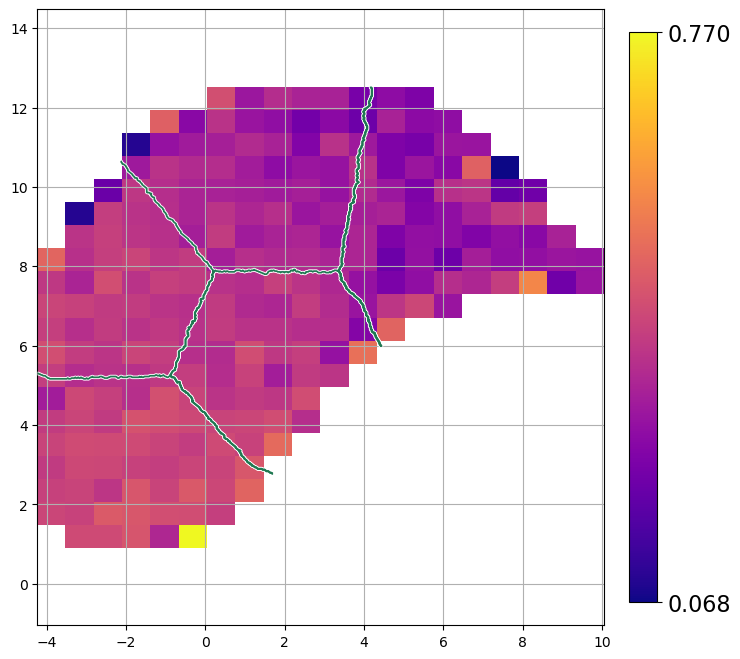

In [8]:
cmap = plt.colormaps["plasma"].copy()
cmap.set_bad(color="white")
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("white")
ax.grid(True)
ax.axis("equal")

# Color scale is based on the bins that remain visible after the min5 display filter.
visible_grid = np.where(display_mask, np.nan, grid_probability_value)
vmin = float(np.nanmin(visible_grid))
vmax = float(np.nanmax(visible_grid))
c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

cluster_embedding = each_pt_embedding
cluster_labels = np.asarray(kmeans_label.labels_)
xx, yy = np.meshgrid(
    np.linspace(min_vals[0], max_vals[0], 600),
    np.linspace(min_vals[1], max_vals[1], 600),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(cluster_embedding, cluster_labels)
Z = knn.predict(grid_points).reshape(xx.shape)

tree = cKDTree(cluster_embedding)
dist, _ = tree.query(grid_points, k=1)
Z_masked = np.ma.masked_where(dist.reshape(xx.shape) > 0.4, Z)

ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="white", linewidths=2.6, alpha=0.95, zorder=10,
)
ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="#1f7952", linewidths=1.2, alpha=1.0, zorder=11,
)

cbar = fig.colorbar(c2, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.3f}", f"{vmax:.3f}"])
cbar.ax.tick_params(labelsize=16)

fig.savefig(OUTPUT_STEM + ".png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_STEM + ".pdf", bbox_inches="tight")
np.savez_compressed(
    OUTPUT_STEM + "_grid.npz",
    grid_count=grid_count,
    grid_mean=grid_probability_value,
    x_bins=x_bins,
    y_bins=y_bins,
    selected_global_idx=selected_global_idx,
    each_pt_embedding=each_pt_embedding,
)
print("Saved:", OUTPUT_STEM + ".png / .pdf / _grid.npz")
plt.show()

## Optional check

Figure 6B is now the **single source** for UMAP coordinates and grid edges; the preceding heatmap cell already checks equality of all 400 bin counts *before* plotting. If the check fails, first verify `B_GRID_PATH`, rerun B's export cell, and make sure both notebooks are reading the same feature data.


In [9]:
print("Reference B file:", os.path.abspath(B_GRID_PATH))
print("Same selected global indices:", np.array_equal(b_selected_idx, selected_global_idx))
print("Same UMAP coordinates:", np.array_equal(b_embedding, each_pt_embedding))
print("Same x/y grid edges:", np.array_equal(x_bins, b_x_bins) and np.array_equal(y_bins, b_y_bins))
print("Same counts in all 400 bins:", np.array_equal(grid_count, b_grid_count))


Reference B file: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/Figure6_B_grid.npz
Same selected global indices: True
Same UMAP coordinates: True
Same x/y grid edges: True
Same counts in all 400 bins: True


Cluster 1 (KMeans label 3): N=8782, Mean=0.4183, SEM=0.0039
Cluster 2 (KMeans label 2): N=5954, Mean=0.3860, SEM=0.0046
Cluster 3 (KMeans label 0): N=6155, Mean=0.3794, SEM=0.0045
Cluster 4 (KMeans label 1): N=5244, Mean=0.3310, SEM=0.0047
Cluster 5 (KMeans label 4): N=4027, Mean=0.2967, SEM=0.0052


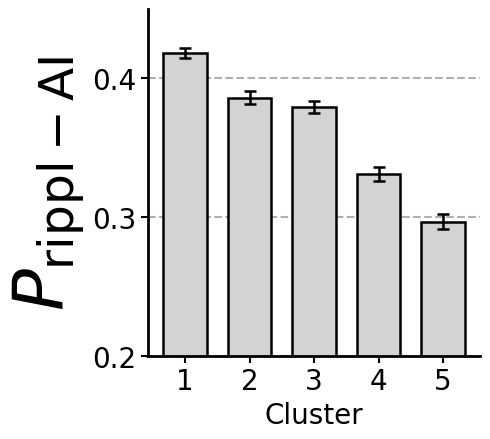

In [12]:
# ======================================================
# Figure 6D: Cluster Mean Rippl-AI Probability ± SEM
# Based on Figure6_D_corrected_v2.ipynb
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# Use the existing results from Figure6_D_corrected_v2
cluster_labels = np.asarray(kmeans_label.labels_)
probabilities = np.asarray(each_pt_probs)

assert len(probabilities) == EXPECTED_SELECTED_N
assert len(cluster_labels) == len(probabilities)

# Preserve the previous Rippl-AI bar display order
cluster_display_order = [3, 2, 0, 1, 4]

cluster_data = [
    probabilities[cluster_labels == cluster_id]
    for cluster_id in cluster_display_order
]

# Calculate cluster mean
cluster_means = [
    np.nanmean(data)
    for data in cluster_data
]

# Calculate cluster SEM
cluster_sems = [
    np.nanstd(data, ddof=1) /
    np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]

# Print actual statistics
for bar_idx, (cluster_id, data, mean, sem) in enumerate(
    zip(
        cluster_display_order,
        cluster_data,
        cluster_means,
        cluster_sems
    ),
    start=1
):
    print(
        f"Cluster {bar_idx} (KMeans label {cluster_id}): "
        f"N={len(data)}, "
        f"Mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )

# ======================================================
# Plot
# ======================================================

labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

ax.bar(
    x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

ax.set_xlabel("Cluster", fontsize=20)

ax.set_ylabel(
    r"$P_{\mathrm{rippl-AI}}$",
    fontsize=50
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)

ax.tick_params(axis="y", labelsize=20)

ax.set_ylim(0.25, 0.45)
ax.set_yticks(np.arange(0.2, 0.45, 0.1))

ax.set_axisbelow(True)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.tick_params(
    axis="both",
    width=1.5,
    length=5
)

plt.tight_layout()

# Save figures
fig.savefig(
    "Figure6_D_corrected_v2_bar.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "Figure6_D_corrected_v2_bar.pdf",
    bbox_inches="tight"
)

plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_probability_scatter(
    embedding,
    probabilities,
    colorbar_label,
    output_stem,
    point_size=4,
    cmap="plasma",
    vmin=None,
    vmax=None
):
    embedding = np.asarray(embedding)
    probabilities = np.asarray(probabilities)

    assert embedding.shape[0] == len(probabilities), \
        f"embedding rows ({embedding.shape[0]}) != probabilities ({len(probabilities)})"

    fig, ax = plt.subplots(figsize=(8, 8))

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=probabilities,
        cmap=cmap,
        s=point_size,
        linewidths=0,
        # alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(True)
    ax.axis("equal")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(colorbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    fig.savefig(output_stem + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(output_stem + ".pdf", bbox_inches="tight")

    plt.show()

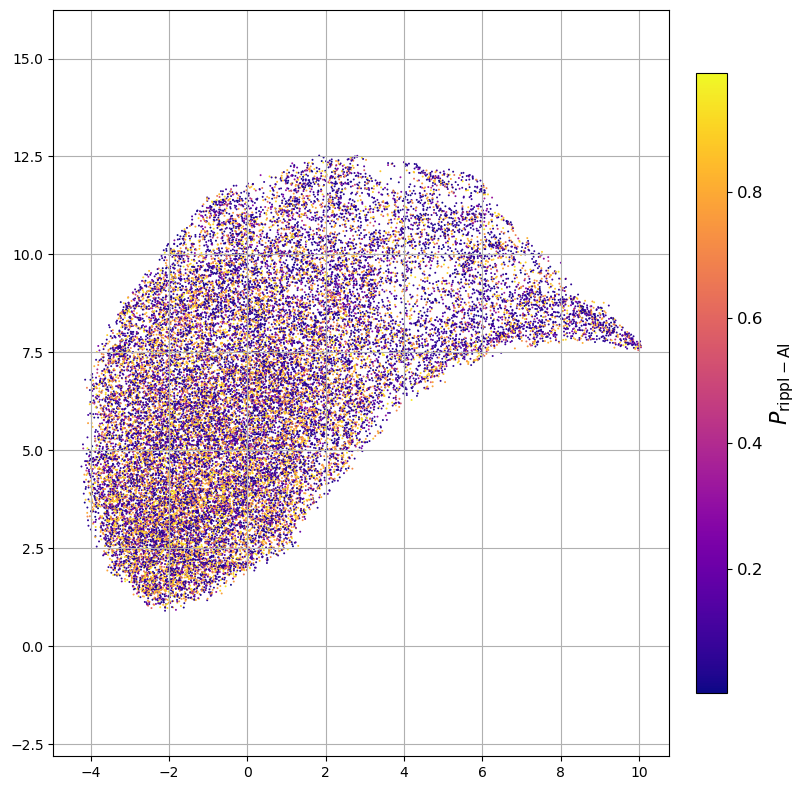

In [15]:
plot_probability_scatter(
    embedding=each_pt_embedding,
    probabilities=each_pt_probs,
    colorbar_label=r"$P_{\mathrm{rippl-AI}}$",
    output_stem="Figure6_D_corrected_scatter",
    point_size=2
)